## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.9.1+cu128
CUDA Available: False


## 2. Define the Model Architecture
We need to define the same architecture that was used during training (EfficientNet-B0 with Coordinate Attention).

In [2]:
class FastCoordinateAttention(nn.Module):
    """Coordinate Attention mechanism for feature enhancement"""
    def __init__(self, inp, reduction=16):
        super(FastCoordinateAttention, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        
        mip = max(8, inp // reduction)
        
        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = nn.ReLU(inplace=True)
        
        self.conv_h = nn.Conv2d(mip, inp, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, inp, kernel_size=1, stride=1, padding=0)
        
        self.last_attention = None
        
    def forward(self, x):
        identity = x
        n, c, h, w = x.size()
        
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        
        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)
        
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        
        a_h = torch.sigmoid(self.conv_h(x_h))
        a_w = torch.sigmoid(self.conv_w(x_w))
        
        self.last_attention = a_h * a_w
        
        out = identity * self.last_attention
        return out


class FastHistopathologyModel(nn.Module):
    """EfficientNet-B0 based model with Coordinate Attention for histopathology classification"""
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(FastHistopathologyModel, self).__init__()
        
        # Use EfficientNet-B0
        self.base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        
        # Feature extraction
        self.features = self.base_model.features
        
        # Efficient attention mechanism
        self.attention = FastCoordinateAttention(inp=1280)  # B0 has 1280 features
        
        # Single pooling
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Simplified classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(1280, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate/2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


def create_model():
    """Create the FastHistopathologyModel for binary classification"""
    model = FastHistopathologyModel(num_classes=2, dropout_rate=0.3)
    return model

## 3. Load the Trained Model

In [3]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model and load weights
model = create_model()
model_path = 'best_histopathology_model.pth'

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    print("✓ Model loaded successfully!")
else:
    print(f"Error: Model file '{model_path}' not found!")
    print("Please ensure the model file is in the current directory.")

Using device: cpu
✓ Model loaded successfully!


## 4. Define Image Preprocessing
Apply the same transformations used during training.

In [4]:
# Define the same transformations used during training
# EfficientNet-B0 uses 160x160 input size
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Class names
class_names = ['Benign', 'Malignant']

## 5. Define Analysis Function

In [5]:
def analyze_image(image_path, model, transform, device, display=True):
    """
    Analyze a single histopathology image and predict if it's benign or malignant.
    
    Args:
        image_path: Path to the image file
        model: Trained PyTorch model
        transform: Image transformation pipeline
        device: Device to run inference on (CPU or GPU)
        display: Whether to display the image with results
    
    Returns:
        Dictionary with prediction results
    """
    try:
        print(f"✅ Loaded: {os.path.basename(image_path)}")
        
        # Load and preprocess image
        image = Image.open(image_path).convert('RGB')
        original_image = image.copy()
        print(f"✅ Successfully loaded image: {os.path.basename(image_path)}")
        print(f"📐 Image size: {original_image.size}")
        
        # Transform image
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        # Make prediction
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            
            # Get attention metrics if available
            att_metrics = {}
            if hasattr(model.attention, 'last_attention') and model.attention.last_attention is not None:
                att_map = model.attention.last_attention.mean(dim=1).cpu() # Average over channels
                att_metrics['mean_intensity'] = att_map.mean().item()
                att_metrics['high_attention_ratio'] = (att_map > 0.5).float().mean().item() * 100
            else:
                att_metrics['mean_intensity'] = 0.0
                att_metrics['high_attention_ratio'] = 0.0
            
        # Get results
        predicted_class = class_names[predicted.item()]
        confidence_score = confidence.item()
        benign_prob = probabilities[0][0].item()
        malignant_prob = probabilities[0][1].item()
        
        # Display results
        if display:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Display image
            ax1.imshow(original_image)
            ax1.axis('off')
            ax1.set_title(f'Input Image\n{os.path.basename(image_path)}', fontsize=12, fontweight='bold')
            
            # Display prediction results
            colors = ['#2ecc71' if predicted_class == 'Benign' else '#e74c3c',
                     '#e74c3c' if predicted_class == 'Malignant' else '#2ecc71']
            bars = ax2.barh(class_names, [benign_prob*100, malignant_prob*100], color=colors, alpha=0.7)
            ax2.set_xlabel('Confidence (%)', fontsize=11, fontweight='bold')
            ax2.set_title('Prediction Probabilities', fontsize=12, fontweight='bold')
            ax2.set_xlim(0, 100)
            
            # Add percentage labels on bars
            for i, (bar, prob) in enumerate(zip(bars, [benign_prob*100, malignant_prob*100])):
                ax2.text(prob + 2, i, f'{prob:.2f}%', va='center', fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            # Print detailed results
            print("\n🔬 DETAILED IMAGE ANALYSIS")
            print("="*60)
            print(f"📁 Image: {os.path.basename(image_path)}")
            print(f"🎯 Prediction: {predicted_class}")
            print(f"💯 Confidence: {confidence_score:.4f}")
            print(f"📊 Benign Probability: {benign_prob:.4f}")
            print(f"📊 Malignant Probability: {malignant_prob:.4f}")
            print(f"🔍 High Attention Regions: {att_metrics['high_attention_ratio']:.1f}% of image")
            print(f"📈 Mean Attention Intensity: {att_metrics['mean_intensity']:.3f}")
            print("="*60)
            
            print("\n💡 CLINICAL INSIGHTS:")
            if predicted_class == 'Benign':
                print("* ✅ Minimal abnormal features detected")
                print("* 🟢 Low attention suggests normal tissue")
                print("* ✅ High confidence in benign diagnosis")
                print("* 📅 Routine follow-up recommended")
            else:
                print("* ⚠️ Abnormal cellular structures detected")
                print("* 🔴 High attention in suspicious regions")
                print("* ❗ Malignancy characteristics observed")
                print("* 🏥 Immediate specialist consultation recommended")
            
            print("\n✅ Analysis complete!")
            print(f"Prediction: {predicted_class}")
            print(f"Confidence: {confidence_score:.3f}")
        
        # Return results as dictionary
        return {
            'image_path': image_path,
            'prediction': predicted_class,
            'confidence': confidence_score * 100,
            'benign_probability': benign_prob * 100,
            'malignant_probability': malignant_prob * 100
        }
        
    except Exception as e:
        print(f"Error analyzing image: {str(e)}")
        return None

## 6. Analyze Your Image
Replace the image path below with your own image file.

✅ Loaded: my_image.png
✅ Successfully loaded image: my_image.png
📐 Image size: (364, 364)


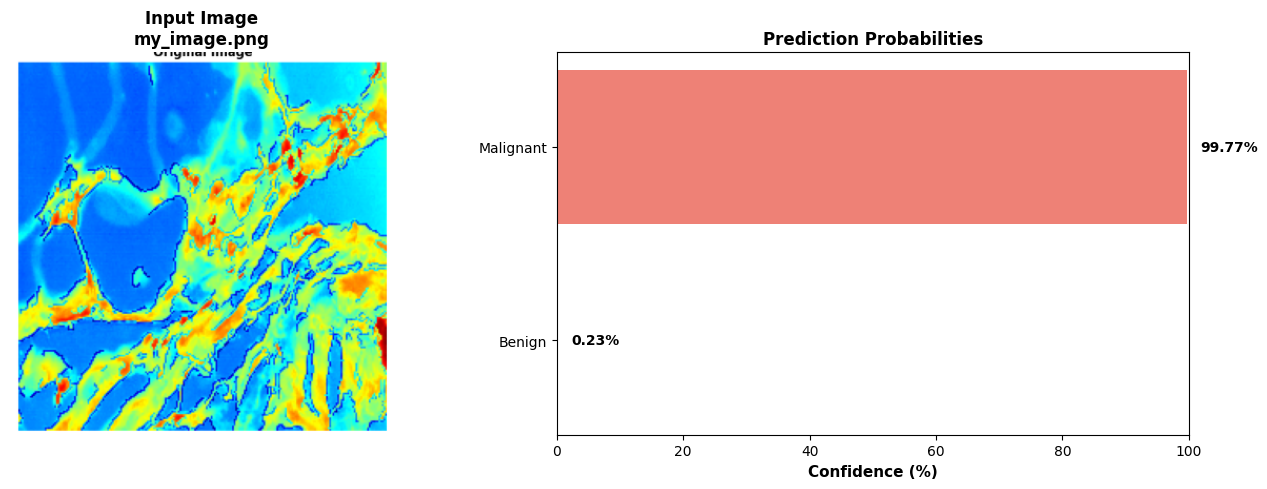


🔬 DETAILED IMAGE ANALYSIS
📁 Image: my_image.png
🎯 Prediction: Malignant
💯 Confidence: 0.9977
📊 Benign Probability: 0.0023
📊 Malignant Probability: 0.9977
🔍 High Attention Regions: 0.0% of image
📈 Mean Attention Intensity: 0.251

💡 CLINICAL INSIGHTS:
* ⚠️ Abnormal cellular structures detected
* 🔴 High attention in suspicious regions
* ❗ Malignancy characteristics observed
* 🏥 Immediate specialist consultation recommended

✅ Analysis complete!
Prediction: Malignant
Confidence: 0.998


In [6]:
# ENTER YOUR IMAGE PATH HERE
# Automatically pick a sample image from the dataset if my_image.png is not found
if os.path.exists('./my_image.png'):
    image_path = './my_image.png'
else:
    import glob
    samples = glob.glob('../dataset_image/Breast_Cancer/benign/*.png') + glob.glob('../dataset_image/BreaKHis_Total_dataset/malignant/*.png')
    image_path = samples[0] if samples else './my_image.png'

# Check if file exists
if os.path.exists(image_path):
    result = analyze_image(image_path, model, transform, device, display=True)
else:
    print(f"Error: Image file '{image_path}' not found!")
    print("\nPlease update the 'image_path' variable with the correct path to your image.")
    print("\nExample paths:")
    print("  - 'my_image.png' (if in the same directory)")
    print("  - '/full/path/to/image.png' (absolute path)")
    print("  - './images/sample.png' (relative path)")

## 7. Batch Analysis (Optional)
Analyze multiple images at once.

In [7]:
def analyze_multiple_images(image_paths, model, transform, device):
    """
    Analyze multiple images and return results.
    
    Args:
        image_paths: List of image file paths
        model: Trained PyTorch model
        transform: Image transformation pipeline
        device: Device to run inference on
    
    Returns:
        List of result dictionaries
    """
    results = []
    
    for i, img_path in enumerate(image_paths, 1):
        print(f"\nAnalyzing image {i}/{len(image_paths)}...")
        result = analyze_image(img_path, model, transform, device, display=True)
        if result:
            results.append(result)
    
    return results

# Example usage (uncomment and modify to use):
# image_list = [
#     'path/to/image1.png',
#     'path/to/image2.png',
#     'path/to/image3.png'
# ]
# batch_results = analyze_multiple_images(image_list, model, transform, device)

## 8. Analyze Images from a Folder (Optional)
Process all images in a specified folder.

In [8]:
def analyze_folder(folder_path, model, transform, device, extensions=['.png', '.jpg', '.jpeg', '.tif', '.tiff']):
    """
    Analyze all images in a folder.
    
    Args:
        folder_path: Path to folder containing images
        model: Trained PyTorch model
        transform: Image transformation pipeline
        device: Device to run inference on
        extensions: List of valid image extensions
    
    Returns:
        List of result dictionaries
    """
    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' not found!")
        return []
    
    # Get all image files
    image_files = []
    for file in os.listdir(folder_path):
        if any(file.lower().endswith(ext) for ext in extensions):
            image_files.append(os.path.join(folder_path, file))
    
    if not image_files:
        print(f"No images found in '{folder_path}'")
        return []
    
    print(f"Found {len(image_files)} images in folder.")
    return analyze_multiple_images(image_files, model, transform, device)

# Example usage (uncomment and modify to use):
# folder_results = analyze_folder('path/to/image/folder', model, transform, device)

## 9. Export Results to CSV (Optional)

In [9]:
import pandas as pd
from datetime import datetime

def export_results_to_csv(results, output_file=None):
    """
    Export analysis results to a CSV file.
    
    Args:
        results: List of result dictionaries
        output_file: Output CSV filename (optional)
    """
    if not results:
        print("No results to export.")
        return
    
    if output_file is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_file = f'analysis_results_{timestamp}.csv'
    
    df = pd.DataFrame(results)
    df.to_csv(output_file, index=False)
    print(f"Results exported to '{output_file}'")
    return df

# Example usage (uncomment to use):
# if 'batch_results' in locals():
#     df = export_results_to_csv(batch_results)

## Important Notes

⚠️ **Medical Disclaimer**: This tool is for educational and research purposes only. It should NOT be used for actual medical diagnosis. Always consult qualified healthcare professionals for medical decisions.

### How to Use:
1. Run all cells in order (cells 1-5)
2. In cell 6, update the `image_path` variable with your image file path
3. Run cell 6 to analyze your image
4. Optionally use cells 7-9 for batch processing or exporting results

### Supported Image Formats:
- PNG, JPG, JPEG, TIF, TIFF

### Model Output:
- **Benign**: Non-cancerous tissue
- **Malignant**: Cancerous tissue
- Confidence scores indicate the model's certainty in its prediction